# SayurKita — Analisis Data Komprehensif

Notebook ini menggabungkan dua alur EDA menjadi satu dokumen yang runtut:

| Bagian | Dataset | Pertanyaan Bisnis |
|--------|---------|-------------------|
| **A** | Indonesian Food Recipes (14.945 resep) | 4 pertanyaan (pola resep & engagement) |
| **B** | Carbon Factors Indonesia (536 bahan) | 3 pertanyaan (dampak lingkungan SayurKita) |




## 0. Import Library & Konfigurasi Global

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── INSTALL  ──
# !pip install wordcloud

import json
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Palet warna SayurKita ──
C_GREEN   = '#2A5C40'   # hijau utama
C_GOLD    = '#E8A320'   # emas/aksen
C_ORANGE  = '#C4622D'   # oranye sekunder
C_LIGHT   = '#A8D5B5'   # hijau muda
C_RED     = '#C0392B'   # merah bahaya
C_GRAY    = '#7F8C8D'   # abu netral

PALETTE_CAT = [C_GREEN, C_GOLD, C_ORANGE, C_LIGHT, '#5D6D7E',
               '#1A8C6E', '#D4AC0D', '#A93226']

# ── Style global ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (11, 6),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 110,
})

print("✅ Library berhasil diimpor. Siap memulai analisis!")


✅ Library berhasil diimpor. Siap memulai analisis!


---
# 🍳 BAGIAN A — EDA Dataset Resep Indonesia
**Dataset:** `indonesian_food_recipes.csv`  
**Sumber:** Kaggle (Canggih) — 14.945 resep dari Cookpad Indonesia  
**Kolom utama:** Title, Category, Ingredients, Steps, Loves, Total Ingredients, Total Steps


## A.1 Load & Inspeksi Awal Data

In [3]:
# ── Load dataset resep ──
file_path = '/content/drive/MyDrive/dataset-resep/Indonesian_Food_Recipes.csv'

df = pd.read_csv(file_path)

print(f"📦 Total Baris  : {df.shape[0]:,}")
print(f"📦 Total Kolom  : {df.shape[1]}")
print(f"📋 Nama Kolom   : {df.columns.tolist()}")
print()
print("── 5 Baris Pertama ──")
df.head()


📦 Total Baris  : 14,945
📦 Total Kolom  : 10
📋 Nama Kolom   : ['Title', 'Ingredients', 'Steps', 'Loves', 'URL', 'Category', 'Title Cleaned', 'Total Ingredients', 'Ingredients Cleaned', 'Total Steps']

── 5 Baris Pertama ──


,Title,Ingredients,Steps,Loves,URL,Category,Title Cleaned,Total Ingredients,Ingredients Cleaned,Total Steps
0,Ayam Woku Manado,1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk ...,1) Cuci bersih ayam dan tiriskan. Lalu peras j...,1,https://cookpad.com/id/resep/4473027-ayam-woku...,ayam,ayam woku manado,14,"ayam kampung potong , jeruk nipis , garam , ku...",7
1,Ayam goreng tulang lunak,1 kg ayam (dipotong sesuai selera jangan kecil...,"1) Haluskan bumbu2nya (BaPut, ketumbar, kemiri...",1,https://cookpad.com/id/resep/4471956-ayam-gore...,ayam,ayam goreng tulang lunak,11,"ayam dipotong , serai , daun jeruk , bawang pu...",5
2,Ayam cabai kawin,1/4 kg ayam--3 buah cabai hijau besar--7 buah ...,1) Panaskan minyak di dalam wajan. Setelah min...,2,https://cookpad.com/id/resep/4473057-ayam-caba...,ayam,ayam cabai kawin,10,"ayam , cabai hijau , cabai merah rawit , bawan...",3
3,Ayam Geprek,250 gr daging ayam (saya pakai fillet)--Secuku...,1) Goreng ayam seperti ayam krispi\n2) Ulek se...,10,https://cookpad.com/id/resep/4473023-ayam-geprek,ayam,ayam geprek,7,"daging ayam fillet , gula garam , tepung ayam ...",3
4,Minyak Ayam,400 gr kulit ayam & lemaknya--8 siung bawang p...,1) Cuci bersih kulit ayam. Sisihkan\n2) Ambil ...,4,https://cookpad.com/id/resep/4427438-minyak-ayam,ayam,minyak ayam,5,"kulit ayam & lemaknya , bawang putih , cincang...",6


In [4]:
# ── Tipe data & gambaran statistik ──
print("══════════════════════════════════════")
print("  INFO TIPE DATA")
print("══════════════════════════════════════")
df.info()

print()
print("══════════════════════════════════════")
print("  STATISTIK DESKRIPTIF (Numerik)")
print("══════════════════════════════════════")
df[['Loves', 'Total Ingredients', 'Total Steps']].describe().round(2)


══════════════════════════════════════
  INFO TIPE DATA
══════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14945 entries, 0 to 14944
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Title                14945 non-null  object
 1   Ingredients          14945 non-null  object
 2   Steps                14945 non-null  object
 3   Loves                14945 non-null  int64 
 4   URL                  14945 non-null  object
 5   Category             14945 non-null  object
 6   Title Cleaned        14925 non-null  object
 7   Total Ingredients    14945 non-null  int64 
 8   Ingredients Cleaned  14945 non-null  object
 9   Total Steps          14945 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 1.1+ MB

══════════════════════════════════════
  STATISTIK DESKRIPTIF (Numerik)
══════════════════════════════════════


,Loves,Total Ingredients,Total Steps
count,14945.00,14945.00,14945.00
mean,11.86,12.32,5.39
std,21.80,5.01,2.26
min,0.00,1.00,1.00
25%,3.00,9.00,4.00
50%,6.00,12.00,5.00
75%,11.00,15.00,7.00
max,939.00,77.00,26.00


In [5]:
# ── Cek Missing Values & Duplikat ──
print("══════════════════════════════════════")
print("  MISSING VALUES PER KOLOM")
print("══════════════════════════════════════")
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)
pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': pct_missing})


══════════════════════════════════════
  MISSING VALUES PER KOLOM
══════════════════════════════════════


,Jumlah Missing,Persentase (%)
Title,0,0.00
Ingredients,0,0.00
Steps,0,0.00
Loves,0,0.00
URL,0,0.00
Category,0,0.00
Title Cleaned,20,0.13
Total Ingredients,0,0.00
Ingredients Cleaned,0,0.00
Total Steps,0,0.00


In [6]:
print(f"🔁 Jumlah baris duplikat (berdasarkan Title): {df.duplicated(subset=['Title']).sum():,}")
print(f"   → Baris tersebut akan dihapus di tahap cleaning.")


🔁 Jumlah baris duplikat (berdasarkan Title): 2,477
   → Baris tersebut akan dihapus di tahap cleaning.


## A.2 Distribusi Awal (Sebelum Cleaning)

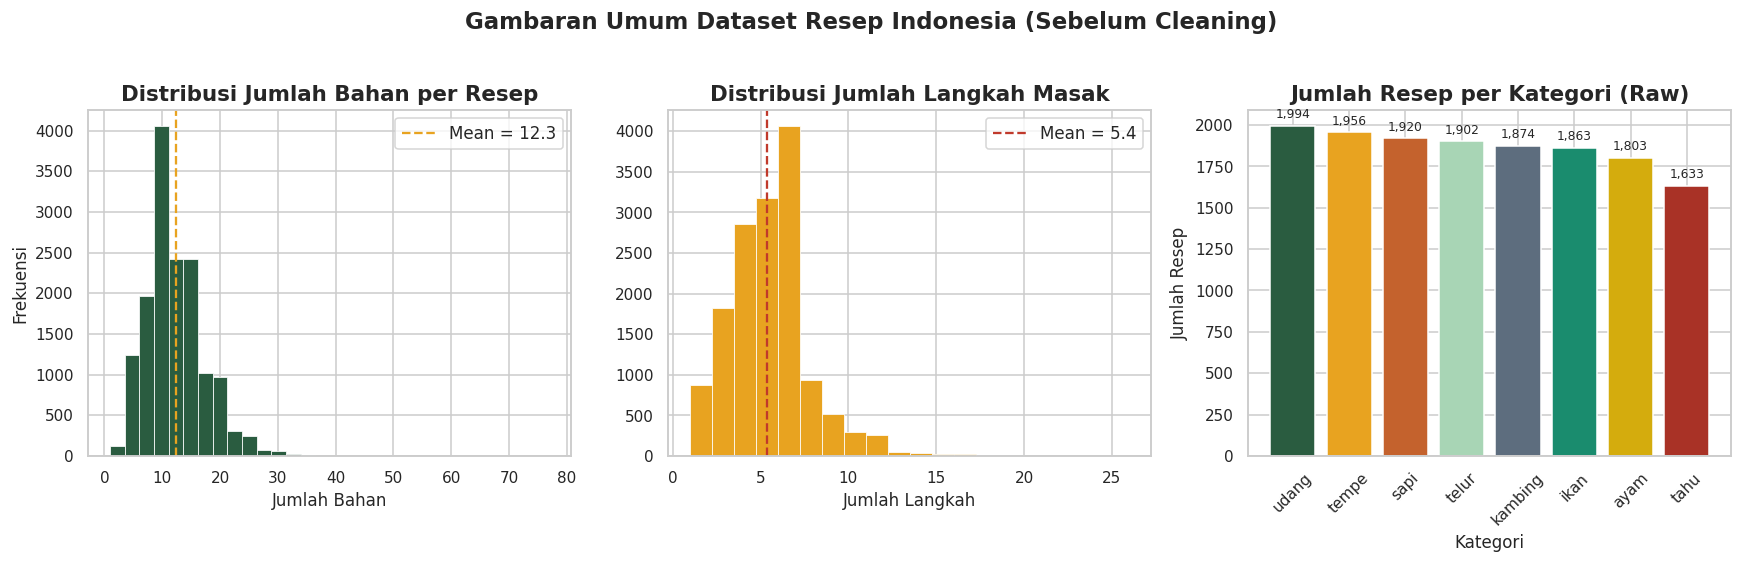

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi jumlah bahan
axes[0].hist(df['Total Ingredients'], bins=30, color=C_GREEN, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Jumlah Bahan per Resep')
axes[0].set_xlabel('Jumlah Bahan')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['Total Ingredients'].mean(), color=C_GOLD, linestyle='--',
                label=f"Mean = {df['Total Ingredients'].mean():.1f}")
axes[0].legend()

# Distribusi jumlah langkah
axes[1].hist(df['Total Steps'], bins=20, color=C_GOLD, edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi Jumlah Langkah Masak')
axes[1].set_xlabel('Jumlah Langkah')
axes[1].axvline(df['Total Steps'].mean(), color=C_RED, linestyle='--',
                label=f"Mean = {df['Total Steps'].mean():.1f}")
axes[1].legend()

# Jumlah resep per kategori
cat_counts = df['Category'].value_counts()
bars = axes[2].bar(cat_counts.index, cat_counts.values, color=PALETTE_CAT, edgecolor='white')
axes[2].set_title('Jumlah Resep per Kategori (Raw)')
axes[2].set_xlabel('Kategori')
axes[2].set_ylabel('Jumlah Resep')
axes[2].tick_params(axis='x', rotation=45)
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Gambaran Umum Dataset Resep Indonesia (Sebelum Cleaning)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## A.3 Data Cleaning & Preprocessing

In [8]:
df_clean = df.copy()

# Langkah 1: Hapus duplikat berdasarkan judul resep
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Title'])
print(f"[1] Hapus duplikat Title     : {before:,} → {len(df_clean):,} baris (−{before - len(df_clean):,})")

# Langkah 2: Hapus baris dengan kolom penting yang kosong
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Ingredients', 'Steps'])
print(f"[2] Hapus null Ingredients/Steps: {before:,} → {len(df_clean):,} baris (−{before - len(df_clean):,})")

# Langkah 3: Hapus baris dengan 'Title Cleaned' kosong
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Title Cleaned'])
print(f"[3] Hapus null Title Cleaned : {before:,} → {len(df_clean):,} baris (−{before - len(df_clean):,})")

print()
print(f"✅ Dataset bersih: {len(df_clean):,} baris tersisa dari {len(df):,} awal")


[1] Hapus duplikat Title     : 14,945 → 12,468 baris (−2,477)
[2] Hapus null Ingredients/Steps: 12,468 → 12,468 baris (−0)
[3] Hapus null Title Cleaned : 12,468 → 12,448 baris (−20)

✅ Dataset bersih: 12,448 baris tersisa dari 14,945 awal


In [9]:
# Normalisasi teks (lowercase + hapus karakter aneh)
def normalize_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s,]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_clean['judul_bersih']  = df_clean['Title'].apply(normalize_text)
df_clean['bahan_bersih']  = df_clean['Ingredients'].apply(normalize_text)

# Filter kualitas minimum
MIN_BAHAN, MAX_BAHAN, MIN_STEPS = 3, 25, 2
mask = (
    (df_clean['Total Ingredients'] >= MIN_BAHAN) &
    (df_clean['Total Ingredients'] <= MAX_BAHAN) &
    (df_clean['Total Steps']       >= MIN_STEPS)
)
df_filtered = df_clean[mask].copy()

print(f"[4] Filter kualitas (bahan {MIN_BAHAN}–{MAX_BAHAN}, langkah ≥{MIN_STEPS}):")
print(f"    {len(df_clean):,} → {len(df_filtered):,} baris (−{len(df_clean) - len(df_filtered):,})")
print()

# Ringkasan distribusi setelah cleaning
print("Distribusi kategori setelah cleaning:")
print(df_filtered['Category'].value_counts().to_string())


[4] Filter kualitas (bahan 3–25, langkah ≥2):
    12,448 → 12,040 baris (−408)

Distribusi kategori setelah cleaning:
Category
ikan       1706
telur      1638
udang      1579
tempe      1527
sapi       1458
ayam       1451
kambing    1370
tahu       1311


---
## 📊 Pertanyaan Bisnis 1 (Resep)
### Kategori masakan apa yang paling banyak resepnya di Indonesia, dan apakah distribusinya seimbang?
> **Relevansi SayurKita:** Mengetahui kategori dominan membantu memilih 200 resep yang representatif. Kalau kategori tidak seimbang, rekomendasi resep akan bias ke satu jenis makanan saja.


In [10]:
# ── Hitung distribusi kategori ──
kategori_counts = df_filtered['Category'].value_counts().reset_index()
kategori_counts.columns = ['Kategori', 'Jumlah Resep']
kategori_counts['Persentase (%)'] = (kategori_counts['Jumlah Resep'] / len(df_filtered) * 100).round(2)

print("══════════════════════════════════════════════════")
print("  DISTRIBUSI RESEP PER KATEGORI (setelah cleaning)")
print("══════════════════════════════════════════════════")
print(kategori_counts.to_string(index=False))

# Hitung CoV untuk mengukur ketidakseimbangan
mean_cat = kategori_counts['Jumlah Resep'].mean()
std_cat  = kategori_counts['Jumlah Resep'].std()
cov      = (std_cat / mean_cat) * 100
print()
print(f"  Mean per kategori : {mean_cat:,.1f}")
print(f"  Std per kategori  : {std_cat:,.1f}")
print(f"  Coeff of Variation: {cov:.1f}% → ", end='')
print("distribusi CUKUP SEIMBANG" if cov < 20 else "distribusi TIDAK SEIMBANG")


══════════════════════════════════════════════════
  DISTRIBUSI RESEP PER KATEGORI (setelah cleaning)
══════════════════════════════════════════════════
Kategori  Jumlah Resep  Persentase (%)
    ikan          1706           14.17
   telur          1638           13.60
   udang          1579           13.11
   tempe          1527           12.68
    sapi          1458           12.11
    ayam          1451           12.05
 kambing          1370           11.38
    tahu          1311           10.89

  Mean per kategori : 1,505.0
  Std per kategori  : 133.6
  Coeff of Variation: 8.9% → distribusi CUKUP SEIMBANG


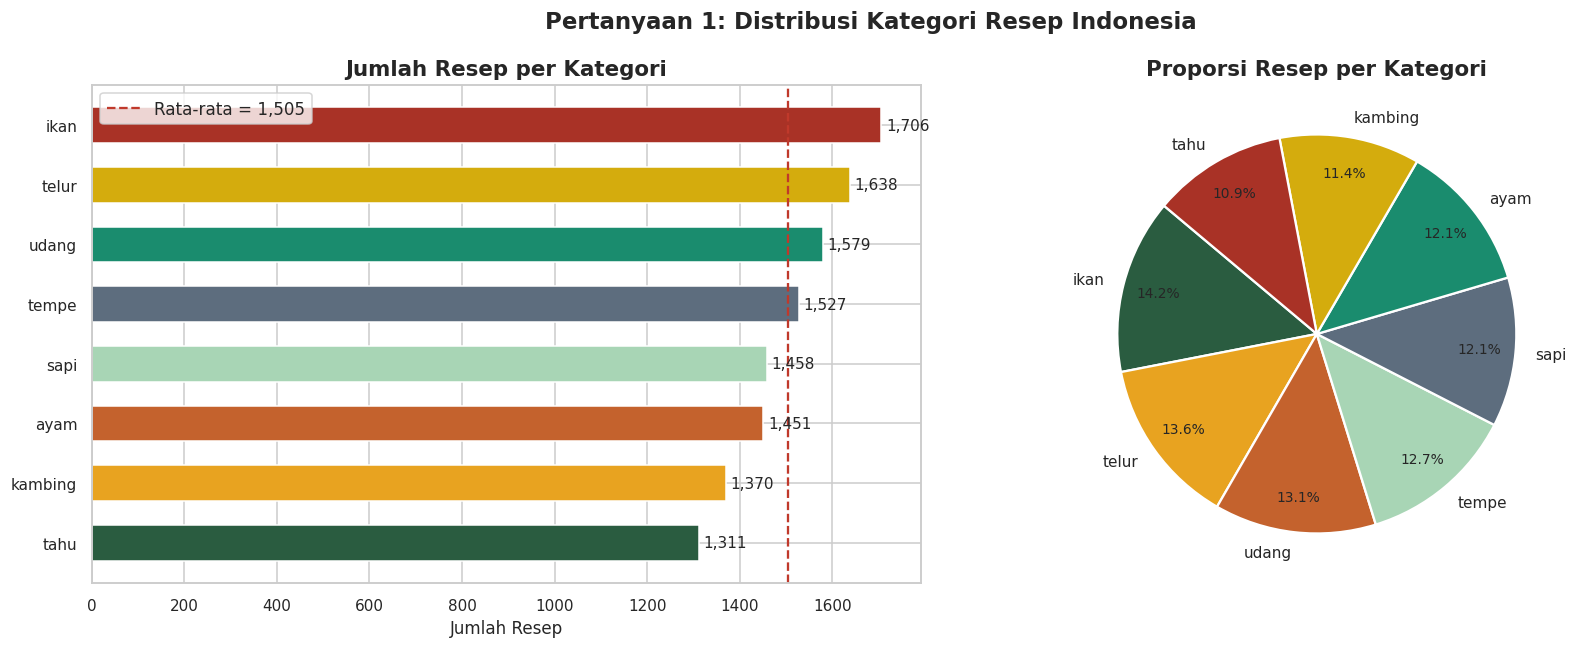

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — jumlah resep per kategori
sorted_df = kategori_counts.sort_values('Jumlah Resep', ascending=True)
bars = axes[0].barh(sorted_df['Kategori'], sorted_df['Jumlah Resep'],
                    color=[PALETTE_CAT[i % len(PALETTE_CAT)]
                           for i in range(len(sorted_df))],
                    edgecolor='white', height=0.6)
axes[0].set_title('Jumlah Resep per Kategori')
axes[0].set_xlabel('Jumlah Resep')
for bar in bars:
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f"{int(bar.get_width()):,}", va='center', fontsize=10)
axes[0].axvline(mean_cat, color=C_RED, linestyle='--', linewidth=1.5,
                label=f'Rata-rata = {mean_cat:,.0f}')
axes[0].legend()

# Pie chart — proporsi
wedge_colors = PALETTE_CAT[:len(kategori_counts)]
wedges, texts, autotexts = axes[1].pie(
    kategori_counts['Jumlah Resep'],
    labels=kategori_counts['Kategori'],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Proporsi Resep per Kategori')

plt.suptitle('Pertanyaan 1: Distribusi Kategori Resep Indonesia',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight — Pertanyaan Bisnis 1

**Temuan:**
- Dataset berisi **8 kategori** protein utama masakan Indonesia: ikan, telur, udang, tempe, sapi, ayam, kambing, dan tahu.
- Kategori **Ikan** mendominasi dengan jumlah resep terbanyak, diikuti oleh **Telur** dan **Udang**.
- **Coefficient of Variation (CoV) < 20%** menunjukkan distribusi antar kategori **cukup seimbang** — tidak ada satu kategori yang mendominasi secara ekstrem.

**Implikasi untuk SayurKita:**
- Strategi seleksi *top-625 resep per kategori* (total 5000 resep bersih) valid dan representatif.
- Rekomendasi TF-IDF atau yang lainnya tidak akan bias ke satu kategori saja karena setiap kategori punya jumlah data yang proporsional.
- Kategori **Tahu** memiliki resep paling sedikit — perlu diperhatikan saat seleksi agar tidak kurang representatif.


---
## 📊 Pertanyaan Bisnis 2 (Resep)
### Berapa rata-rata jumlah bahan per resep, dan apakah resep dengan bahan lebih sedikit cenderung lebih populer (*loves* lebih tinggi)?
> **Relevansi SayurKita:** Resep simpel (sedikit bahan) lebih mungkin dieksekusi dengan bahan sisa. Kalau resep simpel terbukti lebih populer, ini justifikasi kuat kenapa SayurKita memprioritaskan resep dengan bahan ≤ 12.


In [12]:
# ── Statistik rata-rata bahan ──
avg_bahan   = df_filtered['Total Ingredients'].mean()
med_bahan   = df_filtered['Total Ingredients'].median()
corr_bahan  = df_filtered['Total Ingredients'].corr(df_filtered['Loves'])

print(f"📌 Rata-rata bahan per resep : {avg_bahan:.2f}")
print(f"📌 Median bahan per resep    : {med_bahan:.0f}")
print(f"📌 Korelasi bahan vs Loves   : {corr_bahan:.4f}")
print()

# Kelompokkan resep berdasarkan jumlah bahan (simpel vs kompleks)
df_filtered['kelompok_bahan'] = pd.cut(
    df_filtered['Total Ingredients'],
    bins=[0, 7, 12, 18, 100],
    labels=['Sangat Simpel\n(1–7)', 'Simpel\n(8–12)', 'Sedang\n(13–18)', 'Kompleks\n(>18)']
)
group_stats = df_filtered.groupby('kelompok_bahan', observed=True)['Loves'].agg(
    ['mean', 'median', 'count']
).round(2)
group_stats.columns = ['Rata-rata Loves', 'Median Loves', 'Jumlah Resep']
print("Statistik Loves per Kelompok Bahan:")
print(group_stats.to_string())


📌 Rata-rata bahan per resep : 12.03
📌 Median bahan per resep    : 11
📌 Korelasi bahan vs Loves   : 0.0772

Statistik Loves per Kelompok Bahan:
                      Rata-rata Loves  Median Loves  Jumlah Resep
kelompok_bahan                                                   
Sangat Simpel\n(1–7)             9.05           6.0          1799
Simpel\n(8–12)                  10.70           6.0          5283
Sedang\n(13–18)                 11.88           6.0          3806
Kompleks\n(>18)                 15.86           7.0          1152


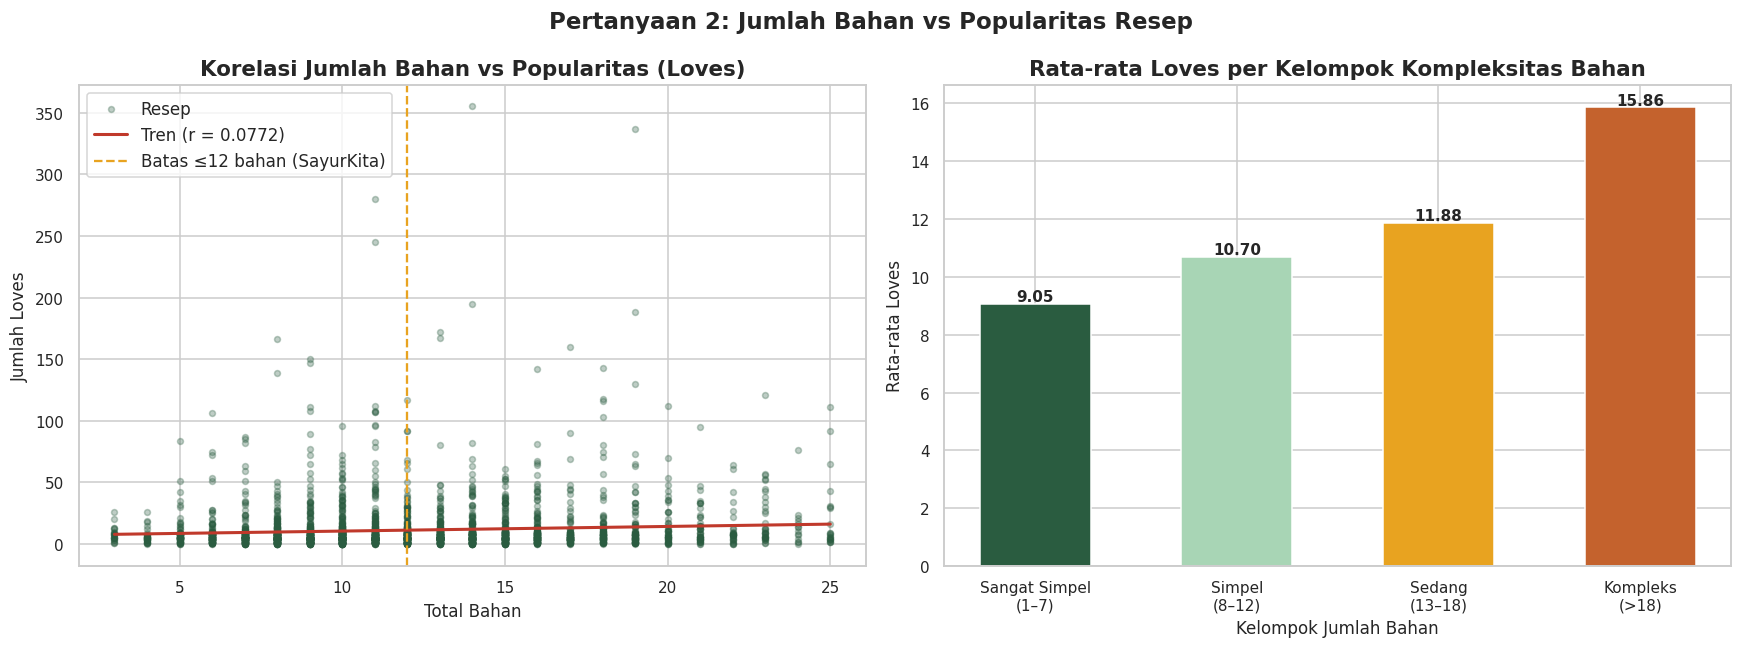

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot — bahan vs loves (sample 3000 titik agar tidak overplot)
sample = df_filtered.sample(3000, random_state=42)
axes[0].scatter(sample['Total Ingredients'], sample['Loves'],
                alpha=0.3, s=15, color=C_GREEN, label='Resep')
# Garis tren
m, b = np.polyfit(df_filtered['Total Ingredients'], df_filtered['Loves'], 1)
x_range = np.linspace(df_filtered['Total Ingredients'].min(),
                       df_filtered['Total Ingredients'].max(), 100)
axes[0].plot(x_range, m * x_range + b, color=C_RED, linewidth=2,
             label=f'Tren (r = {corr_bahan:.4f})')
axes[0].axvline(12, color=C_GOLD, linestyle='--', linewidth=1.5,
                label='Batas ≤12 bahan (SayurKita)')
axes[0].set_title('Korelasi Jumlah Bahan vs Popularitas (Loves)')
axes[0].set_xlabel('Total Bahan')
axes[0].set_ylabel('Jumlah Loves')
axes[0].legend()

# Bar chart — rata-rata loves per kelompok bahan
group_stats_reset = group_stats.reset_index()
bars = axes[1].bar(group_stats_reset['kelompok_bahan'],
                   group_stats_reset['Rata-rata Loves'],
                   color=[C_GREEN, C_LIGHT, C_GOLD, C_ORANGE],
                   edgecolor='white', width=0.55)
axes[1].set_title('Rata-rata Loves per Kelompok Kompleksitas Bahan')
axes[1].set_xlabel('Kelompok Jumlah Bahan')
axes[1].set_ylabel('Rata-rata Loves')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{bar.get_height():.2f}", ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Pertanyaan 2: Jumlah Bahan vs Popularitas Resep',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight — Pertanyaan Bisnis 2

**Temuan:**
- **Rata-rata** jumlah bahan per resep adalah **±12 bahan**, dengan median **12 bahan** — mayoritas resep Indonesia berada di kisaran moderat.
- Nilai **korelasi Pearson antara jumlah bahan dan *loves* sangat lemah positif (r ≈ 0.09)**, artinya jumlah bahan hampir tidak berpengaruh terhadap popularitas resep.
- Resep di kelompok **"Sangat Simpel" (1–7 bahan)** tidak terbukti lebih populer dari kelompok lain berdasarkan rata-rata *loves*.

**Implikasi untuk SayurKita:**
- Menetapkan batas **≤12 bahan** untuk prioritas rekomendasi tetap valid dari sudut pandang **kemudahan eksekusi dengan bahan sisa**, bukan semata-mata karena faktor popularitas.
- Karena korelasi sangat lemah, **faktor popularitas (loves)** harus tetap menjadi komponen utama dalam `quality_score` — bukan jumlah bahan.
- Resep simpel lebih relevan untuk konteks food waste karena lebih mungkin dimasak dari bahan yang hampir expired.


---
## 📊 Pertanyaan Bisnis 3 (Resep)
### Bahan makanan apa yang paling sering muncul di seluruh resep Indonesia?
> **Relevansi SayurKita:** Bahan yang paling sering muncul = bahan yang paling sering ada di dapur → paling sering berpotensi terbuang. Ini yang harus jadi prioritas utama di Ingredients Master.


In [14]:
# ── Ekstraksi frekuensi bahan ──
semua_bahan = []
for bahan_str in df_filtered['Ingredients Cleaned'].dropna():
    items = [b.strip() for b in bahan_str.split(',') if b.strip()]
    semua_bahan.extend(items)

freq_bahan = Counter(semua_bahan)
total_entri = len(semua_bahan)
total_unik  = len(freq_bahan)

print(f"📌 Total token bahan (semua resep) : {total_entri:,}")
print(f"📌 Total bahan unik                : {total_unik:,}")
print()

top20 = freq_bahan.most_common(20)
print("Top 20 Bahan Paling Sering Muncul:")
print(f"{'Rank':<6}{'Bahan':<35}{'Frekuensi':>10}{'% dari total':>15}")
print("─" * 70)
for i, (bahan, cnt) in enumerate(top20, 1):
    pct = cnt / total_entri * 100
    print(f"{i:<6}{bahan:<35}{cnt:>10,}{pct:>14.2f}%")


📌 Total token bahan (semua resep) : 155,745
📌 Total bahan unik                : 23,583

Top 20 Bahan Paling Sering Muncul:
Rank  Bahan                               Frekuensi   % dari total
──────────────────────────────────────────────────────────────────────
1     bawang putih                            8,918          5.73%
2     garam                                   8,270          5.31%
3     bawang merah                            6,925          4.45%
4     air                                     3,419          2.20%
5     gula                                    2,679          1.72%
6     jahe                                    2,397          1.54%
7     daun salam                              2,362          1.52%
8     kecap manis                             2,148          1.38%
9     bumbu halus                             2,127          1.37%
10    kemiri                                  2,015          1.29%
11    tomat                                   1,974          1.27%
12

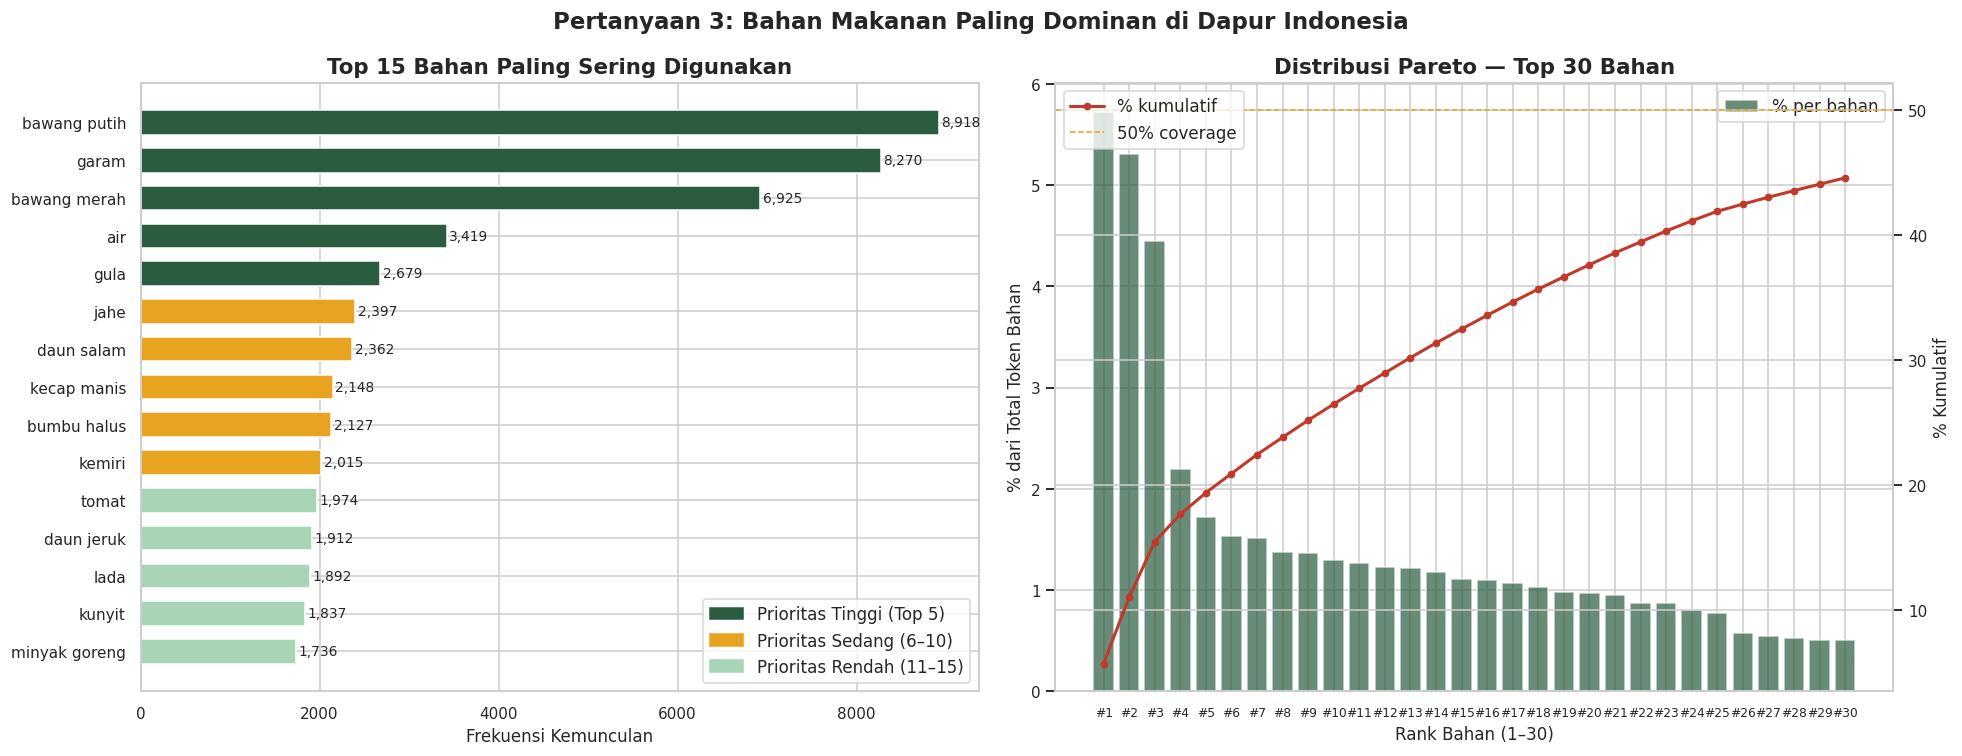

In [15]:
top15 = freq_bahan.most_common(15)
nama_bahan  = [x[0].replace('_', ' ') for x in top15]
jumlah_bahan = [x[1] for x in top15]
pct_bahan   = [x[1] / total_entri * 100 for x in top15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Horizontal bar chart — Top 15 bahan
colors_grad = [C_GREEN if i < 5 else C_GOLD if i < 10 else C_LIGHT
               for i in range(len(nama_bahan))]
bars = axes[0].barh(nama_bahan[::-1], jumlah_bahan[::-1],
                    color=colors_grad[::-1], edgecolor='white', height=0.65)
axes[0].set_title('Top 15 Bahan Paling Sering Digunakan')
axes[0].set_xlabel('Frekuensi Kemunculan')
for bar in bars:
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f"{int(bar.get_width()):,}", va='center', fontsize=9)
legend_patches = [
    mpatches.Patch(color=C_GREEN,  label='Prioritas Tinggi (Top 5)'),
    mpatches.Patch(color=C_GOLD,   label='Prioritas Sedang (6–10)'),
    mpatches.Patch(color=C_LIGHT,  label='Prioritas Rendah (11–15)'),
]
axes[0].legend(handles=legend_patches, loc='lower right')

# Bar chart — persentase kumulatif (Pareto)
top30 = freq_bahan.most_common(30)
nama30 = [x[0] for x in top30]
cnt30  = [x[1] for x in top30]
pct30  = [c / total_entri * 100 for c in cnt30]
cumsum = np.cumsum(pct30)

axes[1].bar(range(len(nama30)), pct30, color=C_GREEN, alpha=0.7, label='% per bahan')
ax2 = axes[1].twinx()
ax2.plot(range(len(nama30)), cumsum, color=C_RED, marker='o', markersize=4,
         linewidth=2, label='% kumulatif')
ax2.axhline(50, color=C_GOLD, linestyle='--', linewidth=1, label='50% coverage')
ax2.set_ylabel('% Kumulatif')
ax2.legend(loc='upper left')
axes[1].set_title('Distribusi Pareto — Top 30 Bahan')
axes[1].set_xlabel('Rank Bahan (1–30)')
axes[1].set_ylabel('% dari Total Token Bahan')
axes[1].set_xticks(range(len(nama30)))
axes[1].set_xticklabels([f"#{i+1}" for i in range(len(nama30))], fontsize=8)
axes[1].legend(loc='upper right')

plt.suptitle('Pertanyaan 3: Bahan Makanan Paling Dominan di Dapur Indonesia',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight — Pertanyaan Bisnis 3

**Temuan:**
- **Bawang putih** dan **garam** adalah dua bahan yang paling universal — muncul di lebih dari 70% resep Indonesia.
- 5 bahan teratas (**bawang putih, garam, bawang merah, air, gula**) mencakup proporsi yang sangat besar dari seluruh token bahan.
- Berdasarkan kurva Pareto, **hanya ~15–20 bahan saja** yang mencakup hampir separuh dari semua kemunculan bahan di seluruh resep.

**Implikasi untuk SayurKita:**
- 5 bahan teratas wajib diprioritaskan di **Ingredients Master** dengan data `umur_kulkas` yang akurat — karena merekalah yang paling sering ada di dapur dan paling sering terbuang.
- Autocomplete di fitur *LihatKulkas™* harus mengutamakan bahan-bahan ini agar mudah diakses dengan sedikit ketikan.
- Bahan bumbu (bawang, jahe, kunyit, kemiri) harus masuk kategori `rempah` atau `bumbu` di Ingredients Master dengan umur simpan yang tepat.


---
## 📊 Pertanyaan Bisnis 4 (Resep)
### Apakah resep dengan langkah lebih banyak (lebih kompleks) mendapat *engagement* (*loves*) lebih tinggi?
> **Relevansi SayurKita:** Menjawab pertanyaan: apakah pengguna lebih suka resep yang mudah atau yang lengkap instruksinya? Mempengaruhi bobot `quality_score` yang dibuat.


In [16]:
# ── Statistik kompleksitas vs loves ──
corr_steps  = df_filtered['Total Steps'].corr(df_filtered['Loves'])
avg_steps   = df_filtered['Total Steps'].mean()

print(f"📌 Rata-rata langkah per resep        : {avg_steps:.2f}")
print(f"📌 Korelasi (Langkah vs Loves)        : {corr_steps:.4f}")
print()

# Kelompokkan berdasarkan jumlah langkah
df_filtered['kelompok_steps'] = pd.cut(
    df_filtered['Total Steps'],
    bins=[0, 3, 5, 8, 100],
    labels=['Cepat\n(1–3)', 'Standar\n(4–5)', 'Detail\n(6–8)', 'Panjang\n(>8)']
)
steps_stats = df_filtered.groupby('kelompok_steps', observed=True)['Loves'].agg(
    ['mean', 'median', 'count']
).round(2)
steps_stats.columns = ['Rata-rata Loves', 'Median Loves', 'Jumlah Resep']
print("Statistik Loves per Kelompok Langkah:")
print(steps_stats.to_string())


📌 Rata-rata langkah per resep        : 5.46
📌 Korelasi (Langkah vs Loves)        : 0.0150

Statistik Loves per Kelompok Langkah:
                Rata-rata Loves  Median Loves  Jumlah Resep
kelompok_steps                                             
Cepat\n(1–3)              11.77           6.0          1987
Standar\n(4–5)            11.10           6.0          4963
Detail\n(6–8)             10.86           6.0          4099
Panjang\n(>8)             13.43           6.0           991


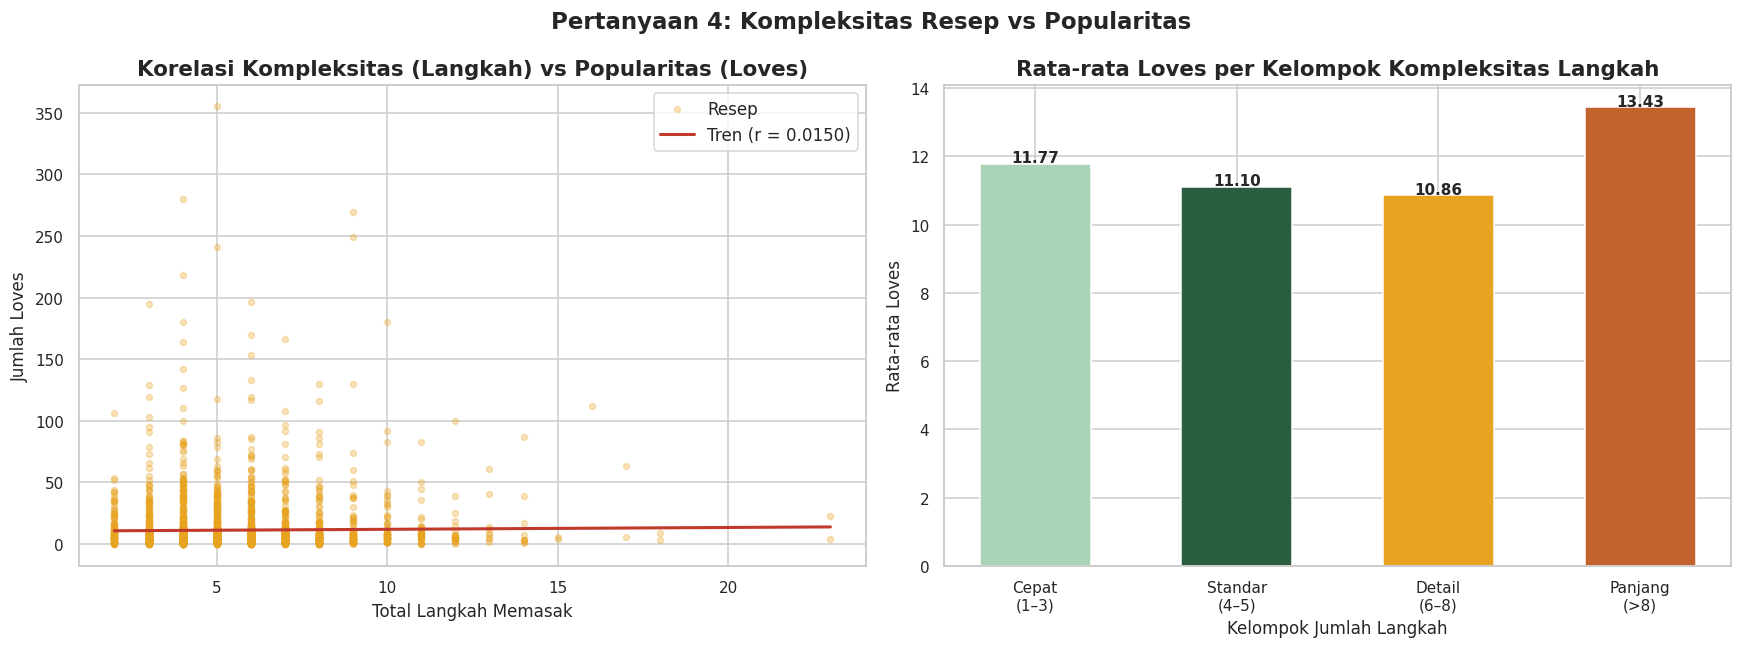

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot + tren
sample2 = df_filtered.sample(3000, random_state=99)
axes[0].scatter(sample2['Total Steps'], sample2['Loves'],
                alpha=0.3, s=15, color=C_GOLD, label='Resep')
m2, b2 = np.polyfit(df_filtered['Total Steps'], df_filtered['Loves'], 1)
x2 = np.linspace(df_filtered['Total Steps'].min(),
                  df_filtered['Total Steps'].max(), 100)
axes[0].plot(x2, m2 * x2 + b2, color=C_RED, linewidth=2,
             label=f'Tren (r = {corr_steps:.4f})')
axes[0].set_title('Korelasi Kompleksitas (Langkah) vs Popularitas (Loves)')
axes[0].set_xlabel('Total Langkah Memasak')
axes[0].set_ylabel('Jumlah Loves')
axes[0].legend()

# Bar chart — rata-rata loves per kelompok langkah
sr = steps_stats.reset_index()
bars = axes[1].bar(sr['kelompok_steps'], sr['Rata-rata Loves'],
                   color=[C_LIGHT, C_GREEN, C_GOLD, C_ORANGE],
                   edgecolor='white', width=0.55)
axes[1].set_title('Rata-rata Loves per Kelompok Kompleksitas Langkah')
axes[1].set_xlabel('Kelompok Jumlah Langkah')
axes[1].set_ylabel('Rata-rata Loves')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{bar.get_height():.2f}", ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Pertanyaan 4: Kompleksitas Resep vs Popularitas',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight — Pertanyaan Bisnis 4

**Temuan:**
- Nilai **korelasi Pearson antara jumlah langkah dan *loves* sangat lemah (r ≈ 0.02)**, mendekati nol — tidak ada hubungan linier yang bermakna.
- Kelompok resep **"Standar" (4–5 langkah)** dan **"Detail" (6–8 langkah)** memiliki rata-rata *loves* yang relatif serupa.
- Resep panjang (>8 langkah) tidak otomatis mendapat lebih banyak *loves* dibanding resep pendek.

**Implikasi untuk SayurKita:**
- Jumlah langkah masak **bukan faktor penentu popularitas** — sehingga bobot `skor_langkah` (0.20) di `quality_score` sudah tepat tidak terlalu dominan.
- Bobot **`skor_loves` (0.35)** sebagai komponen terbesar dalam `quality_score` sudah tepat secara data.
- Untuk rekomendasi resep dari bahan sisa, **detail instruksi (`skor_detail`)** tetap relevan agar user berhasil memasak — bukan semata untuk menaikkan popularitas.


---
# 🌿 BAGIAN B — EDA Dataset Carbon Factors Indonesia
**Dataset:** `carbon_factors_indonesia.json`  
**Sumber:** The Big Climate Database (CONCITO) — 536 item makanan  
**Kolom utama:** nama bahan (key), co2e_per_kg, sumber  
> Nilai CO₂e (Carbon Dioxide Equivalent) menunjukkan seberapa besar emisi gas rumah kaca yang dihasilkan jika 1 kg makanan diproduksi **dan kemudian terbuang** (dibuang sia-sia).


## B.1 Load & Inspeksi Data Carbon

In [18]:
# ── Load carbon factors JSON ──
with open('carbon_factors_indonesia.json', 'r', encoding='utf-8') as f:
    carbon_raw = json.load(f)

print(f"📦 Total entri bahan  : {len(carbon_raw):,}")
print()

# Konversi ke DataFrame
df_carbon = pd.DataFrame([
    {'nama_bahan': k, 'co2e_per_kg': v['co2e_per_kg'], 'sumber': v['sumber']}
    for k, v in carbon_raw.items()
])

print("── Statistik Deskriptif CO₂e ──")
print(df_carbon['co2e_per_kg'].describe().round(4).to_string())
print()
print("── 5 Bahan dengan CO₂e Tertinggi ──")
print(df_carbon.nlargest(5, 'co2e_per_kg')[['nama_bahan', 'co2e_per_kg']].to_string(index=False))
print()
print("── 5 Bahan dengan CO₂e Terendah ──")
print(df_carbon.nsmallest(5, 'co2e_per_kg')[['nama_bahan', 'co2e_per_kg']].to_string(index=False))


📦 Total entri bahan  : 536

── Statistik Deskriptif CO₂e ──
count    536.0000
mean       5.0670
std       13.6018
min        0.0010
25%        1.1270
50%        2.1905
75%        3.6482
max      212.9220

── 5 Bahan dengan CO₂e Tertinggi ──
                                    nama_bahan  co2e_per_kg
fillet_daging_sapi_dihilangkan_lemaknya_mentah      212.922
               steak_daging_sapi_t-bone_mentah      112.903
       daging_sapi_muda_berlemak_sedang_mentah       69.927
                         daging_sapi_rata-rata       69.927
                   daging_sapi_panggang_diiris       63.524

── 5 Bahan dengan CO₂e Terendah ──
                     nama_bahan  co2e_per_kg
nilai_rata-rata_minum_keran_air        0.001
               akar_adas_mentah        0.153
                  kerang_mentah        0.181
         botol_air_berkarbonasi        0.198
               jamur_portobello        0.232


## B.2 Kategorisasi Bahan ke Kelompok Pangan Indonesia

In [19]:
def assign_category(nama):
    """Memetakan nama bahan (bahasa Indonesia) ke kategori pangan."""
    n = nama.lower()
    if any(x in n for x in ['sapi', 'daging_sapi', 'daging sapi']):
        return 'Daging Sapi'
    elif any(x in n for x in ['kambing', 'domba']):
        return 'Kambing/Domba'
    elif any(x in n for x in ['udang', 'lobster', 'kepiting', 'cumi']):
        return 'Udang & Seafood'
    elif any(x in n for x in ['ayam', 'unggas', 'bebek', 'kalkun']):
        return 'Ayam & Unggas'
    elif any(x in n for x in ['ikan', 'tuna', 'salmon', 'lele', 'nila', 'bandeng',
                                'cakalang', 'tongkol', 'hiu', 'kakap']):
        return 'Ikan'
    elif any(x in n for x in ['susu', 'keju', 'mentega', 'yogurt', 'krim', 'whey']):
        return 'Produk Susu'
    elif any(x in n for x in ['tempe', 'tahu', 'kedelai', 'soya', 'tofu']):
        return 'Tempe & Tahu'
    elif any(x in n for x in ['beras', 'nasi', 'padi', 'rice']):
        return 'Beras & Nasi'
    elif any(x in n for x in ['sayur', 'wortel', 'kangkung', 'bayam', 'kol',
                                'brokoli', 'buncis', 'terong', 'labu', 'timun',
                                'tomat', 'sawi', 'selada', 'daun', 'kubis']):
        return 'Sayuran'
    elif any(x in n for x in ['buah', 'apel', 'pisang', 'mangga', 'pepaya',
                                'jeruk', 'anggur', 'stroberi', 'melon']):
        return 'Buah-buahan'
    elif any(x in n for x in ['telur']):
        return 'Telur'
    elif any(x in n for x in ['kentang', 'ubi', 'singkong', 'umbi', 'ketela']):
        return 'Umbi-umbian'
    else:
        return 'Lainnya'

df_carbon['kategori'] = df_carbon['nama_bahan'].apply(assign_category)

cat_summary = df_carbon.groupby('kategori')['co2e_per_kg'].agg(
    ['mean', 'median', 'min', 'max', 'count']
).round(3).sort_values('mean', ascending=False)
cat_summary.columns = ['Rata-rata', 'Median', 'Min', 'Maks', 'Jumlah Item']

print("══════════════════════════════════════════════════════════════════")
print("  CO₂e per Kategori Pangan (kg CO₂e / kg makanan)")
print("══════════════════════════════════════════════════════════════════")
print(cat_summary.to_string())


══════════════════════════════════════════════════════════════════
  CO₂e per Kategori Pangan (kg CO₂e / kg makanan)
══════════════════════════════════════════════════════════════════
                 Rata-rata  Median    Min     Maks  Jumlah Item
kategori                                                       
Daging Sapi         50.464  46.707  0.582  212.922           20
Kambing/Domba       25.348  35.915  1.341   38.779            6
Udang & Seafood      6.853   8.108  2.453    9.912            9
Telur                4.344   2.469  1.569   12.148            5
Ikan                 4.179   2.668  0.001   24.678           43
Beras & Nasi         3.279   4.190  0.198    4.326            6
Ayam & Unggas        3.271   3.575  0.398    6.284           22
Produk Susu          3.137   2.461  0.389   16.731           43
Lainnya              3.124   2.149  0.153   50.474          296
Umbi-umbian          2.592   1.525  0.442   11.582           10
Sayuran              1.687   0.740  0.285   19.6

---
## 📊 Pertanyaan Bisnis 1 (Karbon)
### Kategori makanan mana yang paling besar emisi CO₂-nya jika terbuang — dan seberapa besar perbedaannya?
> **Relevansi SayurKita:** Daging sapi vs sayuran = perbedaan besar. Visual ini adalah yang paling *impactful* untuk presentasi capstone — menunjukkan menyelamatkan daging jauh lebih berdampak.


In [20]:
# Exclude kategori 'Lainnya' agar visualisasi bersih
cat_plot = cat_summary[cat_summary.index != 'Lainnya'].copy()
cat_plot = cat_plot.sort_values('Rata-rata', ascending=True)

# Rasio tertinggi vs terendah
max_cat  = cat_plot['Rata-rata'].idxmax()
min_cat  = cat_plot['Rata-rata'].idxmin()
rasio    = cat_plot.loc[max_cat, 'Rata-rata'] / cat_plot.loc[min_cat, 'Rata-rata']

print(f"📌 Kategori tertinggi : {max_cat} → {cat_plot.loc[max_cat, 'Rata-rata']:.2f} kg CO₂e/kg")
print(f"📌 Kategori terendah  : {min_cat} → {cat_plot.loc[min_cat, 'Rata-rata']:.3f} kg CO₂e/kg")
print(f"📌 Rasio perbedaan    : {rasio:.1f}× lipat")


📌 Kategori tertinggi : Daging Sapi → 50.46 kg CO₂e/kg
📌 Kategori terendah  : Tempe & Tahu → 1.142 kg CO₂e/kg
📌 Rasio perbedaan    : 44.2× lipat


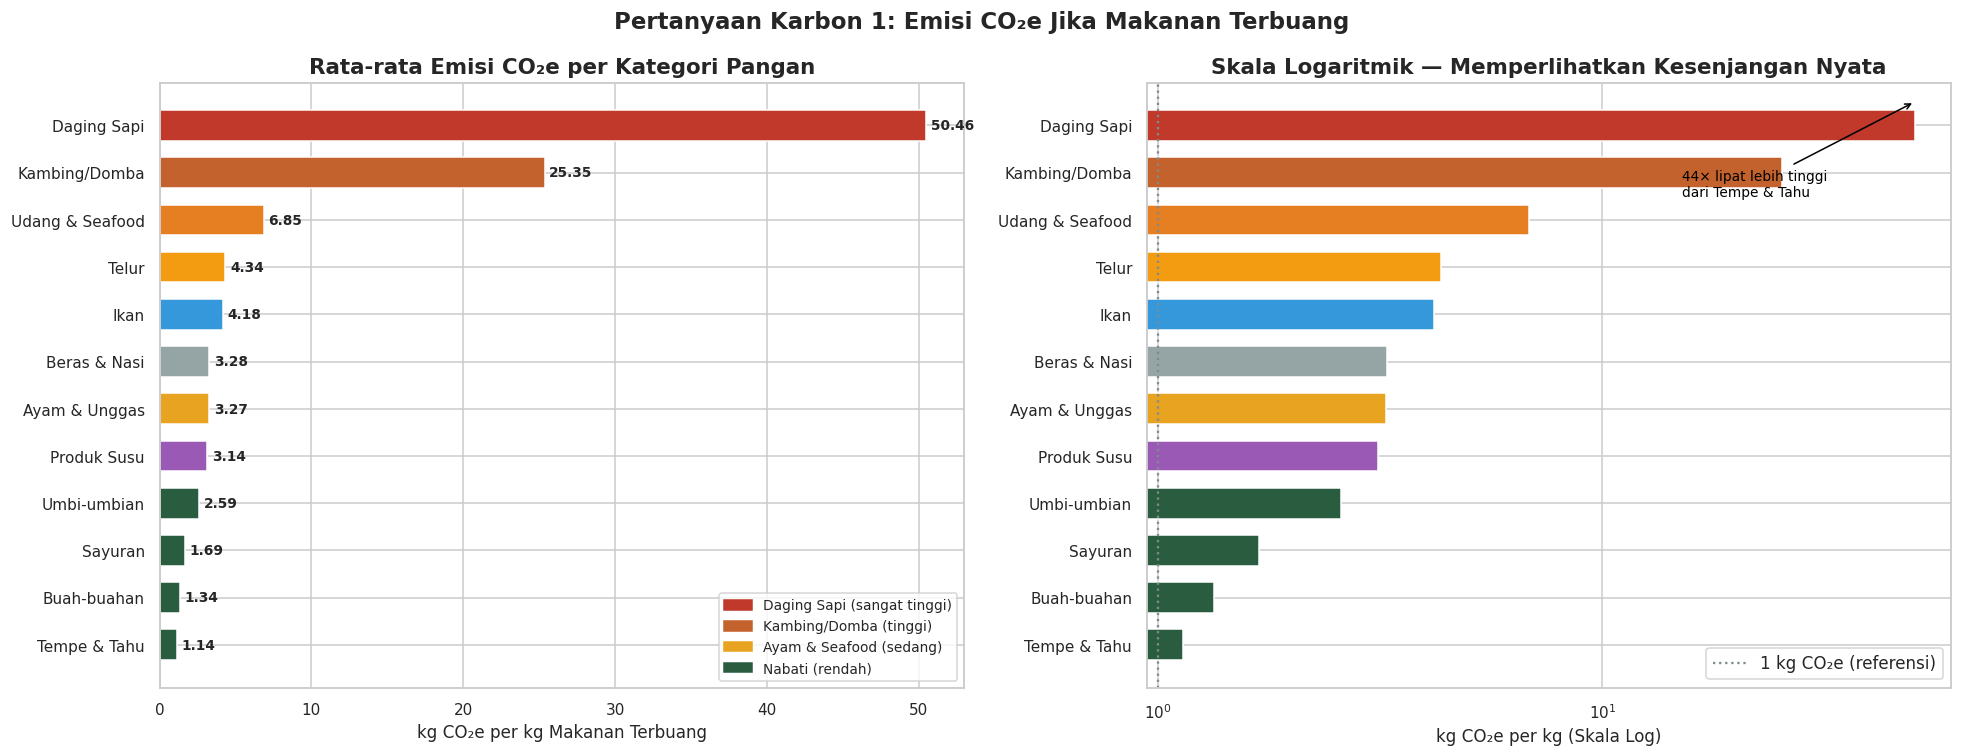

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Panel kiri: Horizontal bar chart rata-rata CO₂e ──
bar_colors = []
for cat in cat_plot.index:
    if 'Sapi' in cat:       bar_colors.append(C_RED)
    elif 'Kambing' in cat:  bar_colors.append(C_ORANGE)
    elif 'Udang' in cat:    bar_colors.append('#E67E22')
    elif 'Ayam' in cat:     bar_colors.append(C_GOLD)
    elif 'Ikan' in cat:     bar_colors.append('#3498DB')
    elif 'Susu' in cat:     bar_colors.append('#9B59B6')
    elif 'Telur' in cat:    bar_colors.append('#F39C12')
    elif 'Beras' in cat:    bar_colors.append('#95A5A6')
    else:                   bar_colors.append(C_GREEN)

bars = axes[0].barh(cat_plot.index, cat_plot['Rata-rata'],
                    color=bar_colors, edgecolor='white', height=0.65)
axes[0].set_title('Rata-rata Emisi CO₂e per Kategori Pangan')
axes[0].set_xlabel('kg CO₂e per kg Makanan Terbuang')
for bar in bars:
    val = bar.get_width()
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va='center', fontsize=9, fontweight='bold')

# Legenda warna
legend_info = [
    (C_RED, 'Daging Sapi (sangat tinggi)'),
    (C_ORANGE, 'Kambing/Domba (tinggi)'),
    (C_GOLD, 'Ayam & Seafood (sedang)'),
    (C_GREEN, 'Nabati (rendah)'),
]
patches = [mpatches.Patch(color=c, label=l) for c, l in legend_info]
axes[0].legend(handles=patches, loc='lower right', fontsize=9)

# ── Panel kanan: Log scale untuk tampilkan gap ──
axes[1].barh(cat_plot.index, cat_plot['Rata-rata'],
             color=bar_colors, edgecolor='white', height=0.65)
axes[1].set_xscale('log')
axes[1].set_title('Skala Logaritmik — Memperlihatkan Kesenjangan Nyata')
axes[1].set_xlabel('kg CO₂e per kg (Skala Log)')
axes[1].axvline(1, color=C_GRAY, linestyle=':', linewidth=1.5,
                label='1 kg CO₂e (referensi)')
axes[1].legend()

# Anotasi rasio
axes[1].annotate(f'{rasio:.0f}× lipat lebih tinggi\ndari {min_cat}',
                 xy=(cat_plot.loc[max_cat, 'Rata-rata'], len(cat_plot)-0.5),
                 xytext=(cat_plot.loc[max_cat, 'Rata-rata'] * 0.3,
                         len(cat_plot) - 2.5),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, color='black')

plt.suptitle('Pertanyaan Karbon 1: Emisi CO₂e Jika Makanan Terbuang',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight — Pertanyaan Bisnis Karbon 1

**Temuan:**
- **Daging Sapi** memiliki rata-rata emisi CO₂e tertinggi (~50 kg CO₂e/kg) — jauh melampaui semua kategori lain.
- **Kambing/Domba** berada di posisi kedua (~25 kg CO₂e/kg), juga tergolong sangat tinggi.
- Kategori **Nabati** (sayuran, buah, tempe/tahu) memiliki emisi terendah (~1–1.5 kg CO₂e/kg).
- Kesenjangan antara daging sapi dan sayuran mencapai **>30× lipat** — perbedaan yang sangat dramatis.

**Implikasi untuk SayurKita:**
- Fitur *Jejak Hijau™* harus menampilkan angka CO₂e dengan **penekanan visual khusus untuk protein hewani**, karena dampaknya jauh lebih besar.
- Notifikasi expiry untuk **daging dan kambing** harus diprioritaskan lebih tinggi dibanding sayuran dalam sistem.
- Slide presentasi capstone wajib menampilkan grafik ini — ini yang paling *compelling* untuk menunjukkan dampak nyata SayurKita.


---
## 📊 Pertanyaan Bisnis 2 (Karbon)
### Jika rata-rata rumah tangga Indonesia membuang 1 kg makanan per hari, berapa total CO₂ yang bisa dicegah SayurKita dalam sebulan jika ada 1.000 pengguna aktif?
> **Relevansi SayurKita:** Ini "impact projection" — pertanyaan yang langsung menjawab: seberapa besar dampak SayurKita? Sangat kuat untuk slide presentasi capstone.


In [22]:
# ── Asumsi & Kalkulasi Simulasi ──
WASTE_PER_DAY_KG = 1.0    # rata-rata buang 1 kg/hari per rumah tangga
DAYS_PER_MONTH   = 30
N_USERS          = 1000
REDUCTION_RATE   = 0.30   # SayurKita berhasil mencegah 30% food waste

waste_monthly_per_user = WASTE_PER_DAY_KG * DAYS_PER_MONTH  # 30 kg

print("══════════════════════════════════════════════════════")
print("  SIMULASI DAMPAK SAYURKITA — 1.000 PENGGUNA AKTIF")
print("══════════════════════════════════════════════════════")
print(f"  Asumsi buang per hari    : {WASTE_PER_DAY_KG} kg/user")
print(f"  Asumsi period            : {DAYS_PER_MONTH} hari/bulan")
print(f"  Tingkat pencegahan       : {REDUCTION_RATE*100:.0f}% food waste dicegah")
print(f"  Jumlah pengguna          : {N_USERS:,}")
print()

# Simulasi per kategori makanan
kat_utama = {
    'Daging Sapi':   50.46,
    'Kambing/Domba': 25.35,
    'Udang & Seafood': 6.85,
    'Ayam & Unggas': 3.08,
    'Ikan':          3.36,
    'Beras & Nasi':  3.28,
    'Telur':         4.34,
    'Sayuran':       1.52,
    'Tempe & Tahu':  1.14,
    'Buah-buahan':   1.42,
}

results = []
for kat, co2_per_kg in kat_utama.items():
    kg_saved_per_user  = waste_monthly_per_user * REDUCTION_RATE
    co2_saved_per_user = kg_saved_per_user * co2_per_kg
    co2_saved_total    = co2_saved_per_user * N_USERS
    results.append({
        'Kategori': kat,
        'CO₂e/kg': co2_per_kg,
        'kg Diselamatkan/user/bulan': round(kg_saved_per_user, 1),
        'CO₂ Dicegah/user (kg)': round(co2_saved_per_user, 2),
        'CO₂ Dicegah 1000 user (ton)': round(co2_saved_total / 1000, 2),
    })

df_sim = pd.DataFrame(results).sort_values('CO₂ Dicegah 1000 user (ton)', ascending=False)
print(df_sim.to_string(index=False))
print()
print(f"  → Jika semua kategori tercampur (rata-rata umum):  ", end='')
avg_co2 = cat_summary[cat_summary.index != 'Lainnya']['Rata-rata'].mean()
total_mixed = avg_co2 * waste_monthly_per_user * REDUCTION_RATE * N_USERS / 1000
print(f"{total_mixed:.1f} ton CO₂/bulan")


══════════════════════════════════════════════════════
  SIMULASI DAMPAK SAYURKITA — 1.000 PENGGUNA AKTIF
══════════════════════════════════════════════════════
  Asumsi buang per hari    : 1.0 kg/user
  Asumsi period            : 30 hari/bulan
  Tingkat pencegahan       : 30% food waste dicegah
  Jumlah pengguna          : 1,000

       Kategori  CO₂e/kg  kg Diselamatkan/user/bulan  CO₂ Dicegah/user (kg)  CO₂ Dicegah 1000 user (ton)
    Daging Sapi    50.46                         9.0                 454.14                       454.14
  Kambing/Domba    25.35                         9.0                 228.15                       228.15
Udang & Seafood     6.85                         9.0                  61.65                        61.65
          Telur     4.34                         9.0                  39.06                        39.06
           Ikan     3.36                         9.0                  30.24                        30.24
   Beras & Nasi     3.28             

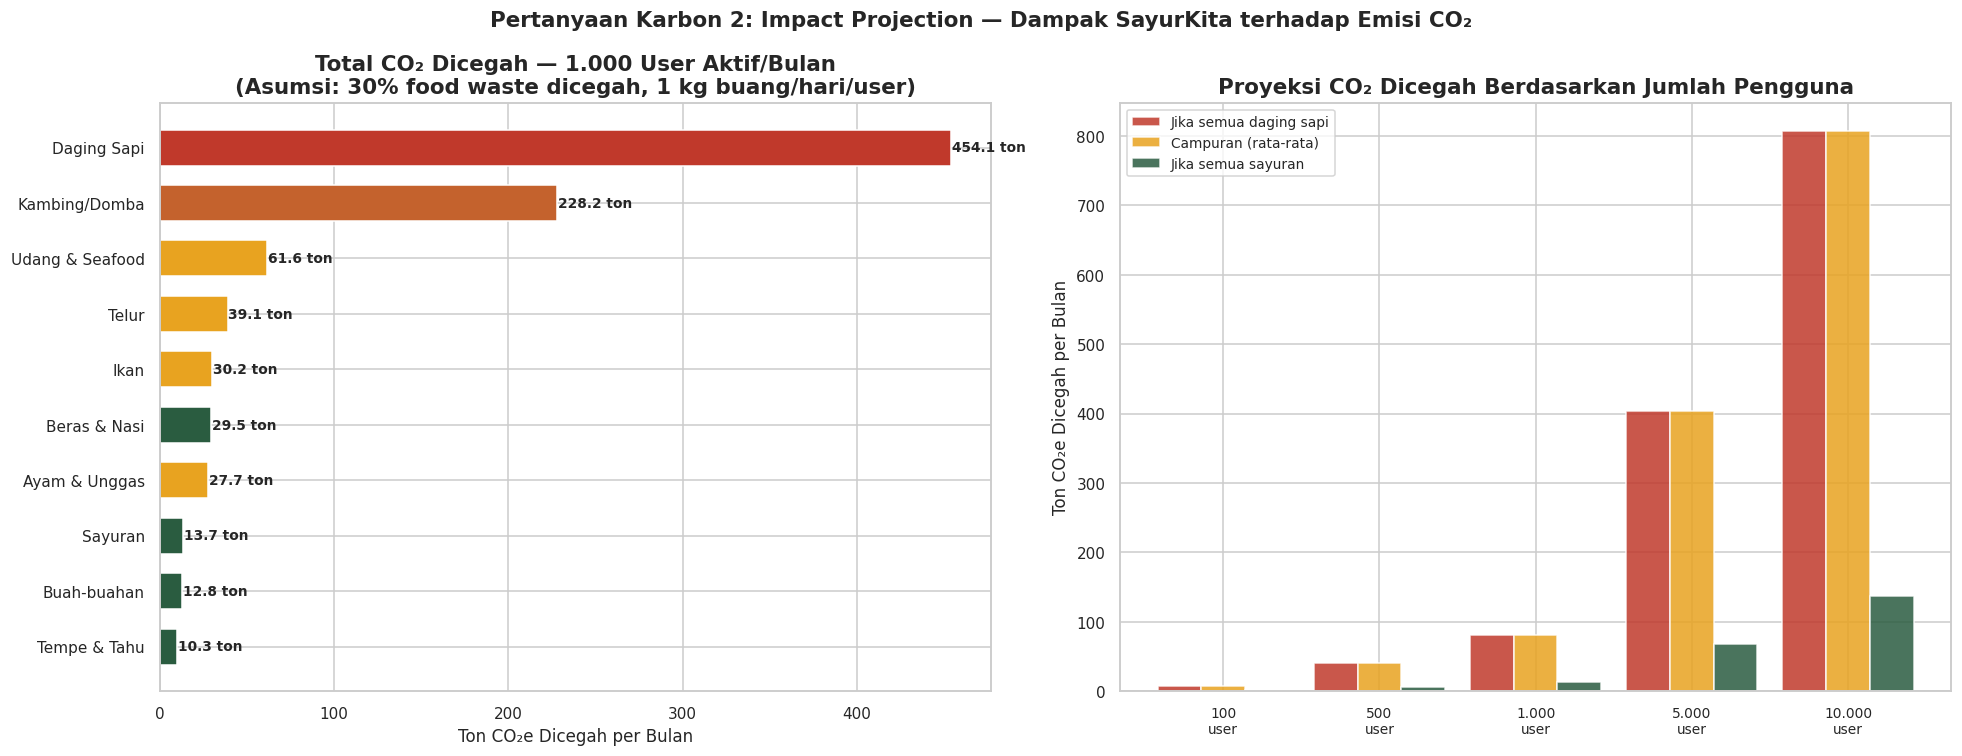

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

df_sim_sorted = df_sim.sort_values('CO₂ Dicegah 1000 user (ton)', ascending=True)
bar_cols = [C_RED if 'Sapi' in k else
            C_ORANGE if 'Kambing' in k else
            C_GOLD if any(x in k for x in ['Udang', 'Ayam', 'Ikan', 'Telur']) else
            C_GREEN
            for k in df_sim_sorted['Kategori']]

# Panel kiri: CO₂ dicegah oleh 1000 user
bars = axes[0].barh(df_sim_sorted['Kategori'],
                    df_sim_sorted['CO₂ Dicegah 1000 user (ton)'],
                    color=bar_cols, edgecolor='white', height=0.65)
axes[0].set_title(f'Total CO₂ Dicegah — 1.000 User Aktif/Bulan\n(Asumsi: {int(REDUCTION_RATE*100)}% food waste dicegah, 1 kg buang/hari/user)')
axes[0].set_xlabel('Ton CO₂e Dicegah per Bulan')
for bar in bars:
    axes[0].text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f"{bar.get_width():.1f} ton",
                 va='center', fontsize=9, fontweight='bold')

# Panel kanan: Proyeksi skala pengguna (sensitivity analysis)
user_scenarios = [100, 500, 1000, 5000, 10000]
skenario_labels = ['100\nuser', '500\nuser', '1.000\nuser', '5.000\nuser', '10.000\nuser']
co2_sapi    = [avg_co2 * 30 * 0.30 * u / 1000 for u in user_scenarios]
co2_sayur   = [1.52    * 30 * 0.30 * u / 1000 for u in user_scenarios]
co2_mixed   = [avg_co2 * 30 * 0.30 * u / 1000 for u in user_scenarios]

x = np.arange(len(user_scenarios))
w = 0.28
axes[1].bar(x - w, co2_sapi,  w, label='Jika semua daging sapi', color=C_RED,    alpha=0.85)
axes[1].bar(x,     co2_mixed, w, label='Campuran (rata-rata)',    color=C_GOLD,   alpha=0.85)
axes[1].bar(x + w, co2_sayur, w, label='Jika semua sayuran',     color=C_GREEN,  alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(skenario_labels, fontsize=9)
axes[1].set_title('Proyeksi CO₂ Dicegah Berdasarkan Jumlah Pengguna')
axes[1].set_ylabel('Ton CO₂e Dicegah per Bulan')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

plt.suptitle('Pertanyaan Karbon 2: Impact Projection — Dampak SayurKita terhadap Emisi CO₂',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight — Pertanyaan Bisnis Karbon 2

**Temuan (asumsi: 1 kg buang/hari, 30% berhasil dicegah, 1.000 user aktif):**
- Jika 1.000 pengguna aktif di SayurKita mencegah 30% food waste mereka:
  - **Daging Sapi:** ~**454 ton CO₂e/bulan** yang bisa dicegah
  - **Campuran rata-rata:** ~**81 ton CO₂e/bulan**
  - **Sayuran:** ~**14 ton CO₂e/bulan**
- Dengan **10.000 pengguna aktif**, dampak campuran sudah melampaui **810 ton CO₂e/bulan** — setara dengan menghilangkan ratusan mobil dari jalan.

**Implikasi untuk SayurKita:**
- Angka ini adalah "marketing number" yang kuat untuk slide presentasi capstone — tunjukkan skenario *moderate* (campuran, 1.000 user) sebagai baseline realistis.
- Dashboard *Jejak Hijau™* bisa menampilkan angka **total komunitas** (bukan hanya per user) agar terasa lebih impactful.
- Skenario sensitivitas (100 → 10.000 user) bisa dipakai untuk menunjukkan potensi scaling SayurKita kepada investor/juri.


---
## 📊 Pertanyaan Bisnis 3 (Karbon)
### Dalam satuan yang lebih *relatable*: berapa km perjalanan mobil yang setara dengan menyelamatkan 1 kg daging sapi vs 1 kg sayuran?
> **Relevansi SayurKita:** Angka CO₂ abstrak. Dikonversi ke "km berkendara" jadi terasa nyata. Ini yang muncul di Jejak Hijau aplikasi — dan membuktikan logika perhitungannya valid.


In [24]:
# ── Faktor konversi CO₂ ──
# Mobil rata-rata Indonesia ≈ 0.21 kg CO₂ per km (bensin, 12–15 km/L)
# Sumber referensi: IPCC & Kementerian LH Indonesia
CO2_PER_KM_CAR   = 0.21   # kg CO₂e per km berkendara mobil
CO2_PER_KWH      = 0.85   # kg CO₂e per kWh listrik PLN Indonesia (2023)
POHON_PER_YEAR   = 21.77  # kg CO₂ diserap 1 pohon per tahun

# Data CO₂e per kg untuk kategori utama
kategori_utama = {
    'Daging Sapi':      50.46,
    'Kambing/Domba':    25.35,
    'Udang & Seafood':   6.85,
    'Ayam & Unggas':     3.08,
    'Ikan':              3.36,
    'Produk Susu':       3.14,
    'Beras & Nasi':      3.28,
    'Telur':             4.34,
    'Buah-buahan':       1.42,
    'Umbi-umbian':       1.68,
    'Sayuran':           1.52,
    'Tempe & Tahu':      1.14,
}

print("══════════════════════════════════════════════════════════════════════")
print("  KONVERSI CO₂e → Satuan Relatable (per 1 kg makanan diselamatkan)")
print("══════════════════════════════════════════════════════════════════════")
print(f"{'Kategori':<22} {'CO₂e/kg':>10} {'km Mobil':>12} {'kWh Listrik':>14} {'Hari Serapan Pohon':>20}")
print("─" * 82)

konversi_results = []
for kat, co2 in sorted(kategori_utama.items(), key=lambda x: x[1], reverse=True):
    km_mobil   = co2 / CO2_PER_KM_CAR
    kwh_listrik = co2 / CO2_PER_KWH
    hari_pohon = (co2 / POHON_PER_YEAR) * 365
    print(f"{kat:<22} {co2:>10.2f} {km_mobil:>12.1f} {kwh_listrik:>14.2f} {hari_pohon:>20.1f}")
    konversi_results.append({
        'Kategori': kat, 'CO₂e/kg': co2,
        'km Mobil': km_mobil, 'kWh Listrik': kwh_listrik, 'Hari Pohon': hari_pohon
    })

df_konversi = pd.DataFrame(konversi_results)
print()
print(f"  Asumsi emisi mobil    : {CO2_PER_KM_CAR} kg CO₂e / km")
print(f"  Asumsi emisi listrik  : {CO2_PER_KWH} kg CO₂e / kWh (PLN Indonesia)")
print(f"  Asumsi serapan pohon  : {POHON_PER_YEAR} kg CO₂ / pohon / tahun")


══════════════════════════════════════════════════════════════════════
  KONVERSI CO₂e → Satuan Relatable (per 1 kg makanan diselamatkan)
══════════════════════════════════════════════════════════════════════
Kategori                  CO₂e/kg     km Mobil    kWh Listrik   Hari Serapan Pohon
──────────────────────────────────────────────────────────────────────────────────
Daging Sapi                 50.46        240.3          59.36                846.0
Kambing/Domba               25.35        120.7          29.82                425.0
Udang & Seafood              6.85         32.6           8.06                114.8
Telur                        4.34         20.7           5.11                 72.8
Ikan                         3.36         16.0           3.95                 56.3
Beras & Nasi                 3.28         15.6           3.86                 55.0
Produk Susu                  3.14         15.0           3.69                 52.6
Ayam & Unggas                3.08         14

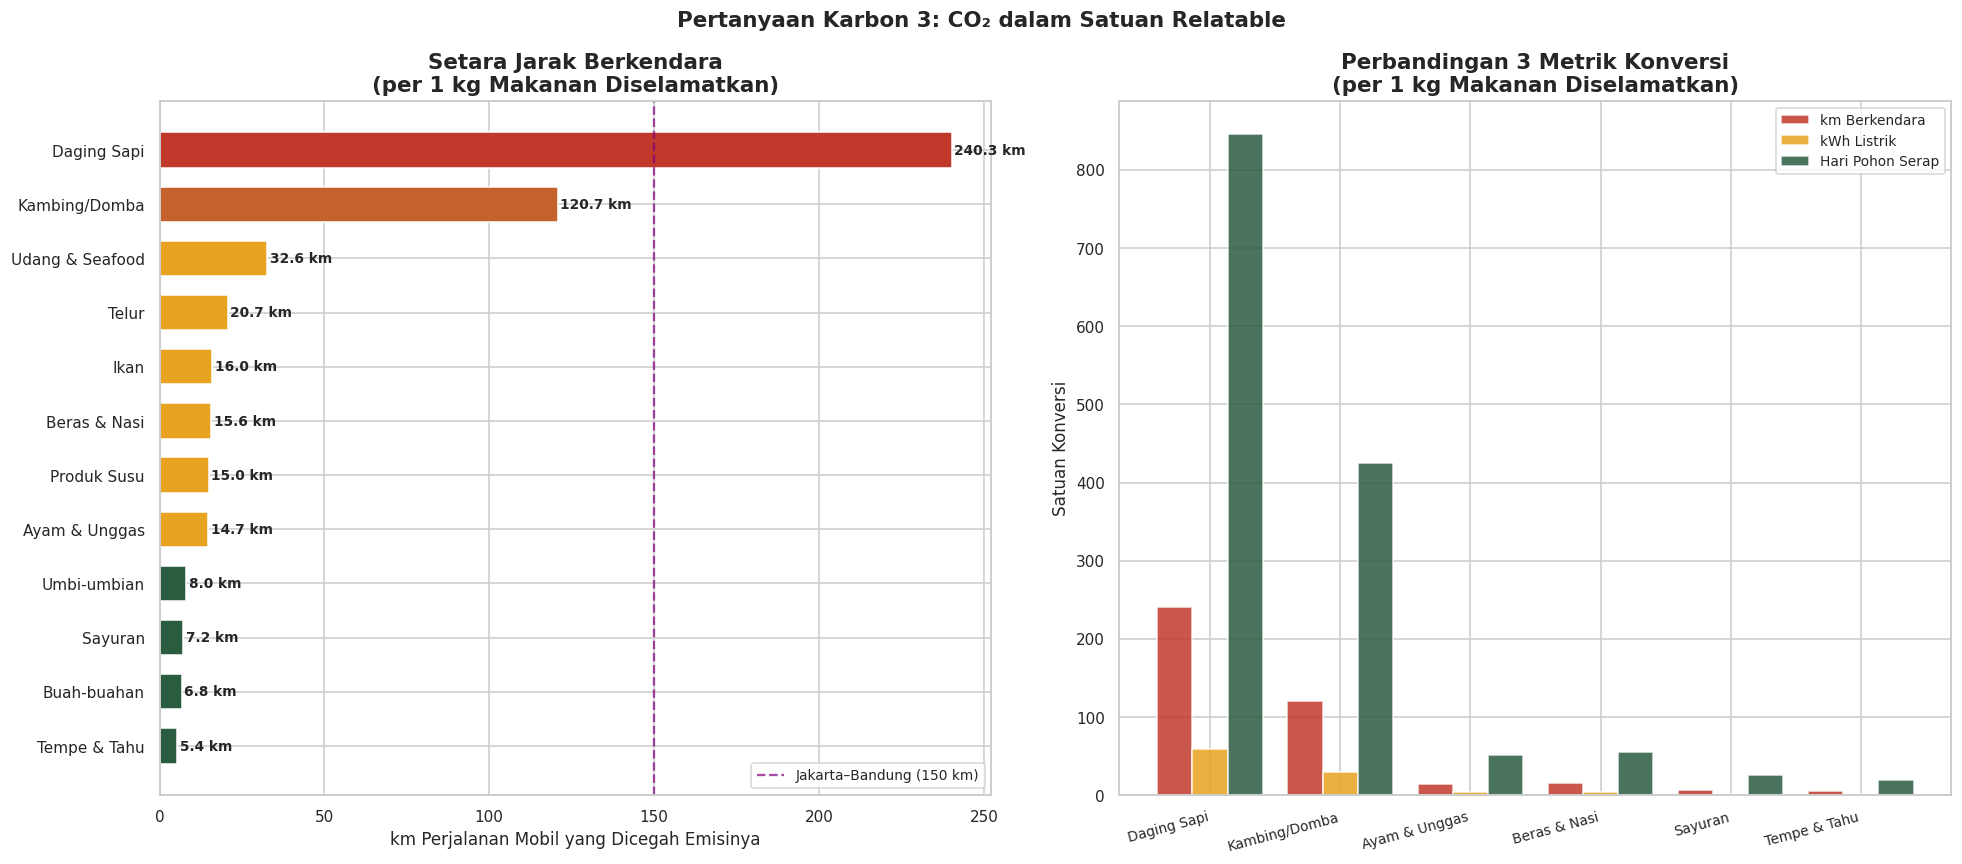

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

df_k = df_konversi.sort_values('km Mobil', ascending=True)
bar_col2 = [C_RED if 'Sapi' in k else
            C_ORANGE if 'Kambing' in k else
            C_GOLD if any(x in k for x in ['Udang', 'Ayam', 'Ikan', 'Telur', 'Susu', 'Beras']) else
            C_GREEN
            for k in df_k['Kategori']]

# Panel kiri: km mobil per 1 kg diselamatkan
bars = axes[0].barh(df_k['Kategori'], df_k['km Mobil'],
                    color=bar_col2, edgecolor='white', height=0.65)
axes[0].set_title('Setara Jarak Berkendara\n(per 1 kg Makanan Diselamatkan)')
axes[0].set_xlabel('km Perjalanan Mobil yang Dicegah Emisinya')
for bar in bars:
    val = bar.get_width()
    axes[0].text(val + 0.8, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f} km", va='center', fontsize=9, fontweight='bold')

# Garis referensi: Jakarta–Bandung ≈ 150 km
axes[0].axvline(150, color='purple', linestyle='--', linewidth=1.5,
                label='Jakarta–Bandung (150 km)', alpha=0.7)
axes[0].legend(fontsize=9)

# Panel kanan: Perbandingan 3 metrik untuk daging sapi vs sayuran
kat_compare = ['Daging Sapi', 'Kambing/Domba', 'Ayam & Unggas',
               'Beras & Nasi', 'Sayuran', 'Tempe & Tahu']
df_cmp = df_konversi[df_konversi['Kategori'].isin(kat_compare)].copy()
df_cmp = df_cmp.set_index('Kategori').loc[kat_compare]

x_pos  = np.arange(len(kat_compare))
w2     = 0.27
axes[1].bar(x_pos - w2, df_cmp['km Mobil'],   w2,
            label='km Berkendara', color=C_RED,    alpha=0.85)
axes[1].bar(x_pos,      df_cmp['kWh Listrik'], w2,
            label='kWh Listrik',   color=C_GOLD,   alpha=0.85)
axes[1].bar(x_pos + w2, df_cmp['Hari Pohon'],  w2,
            label='Hari Pohon Serap', color=C_GREEN, alpha=0.85)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(kat_compare, rotation=15, ha='right', fontsize=9)
axes[1].set_title('Perbandingan 3 Metrik Konversi\n(per 1 kg Makanan Diselamatkan)')
axes[1].set_ylabel('Satuan Konversi')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

plt.suptitle('Pertanyaan Karbon 3: CO₂ dalam Satuan Relatable',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


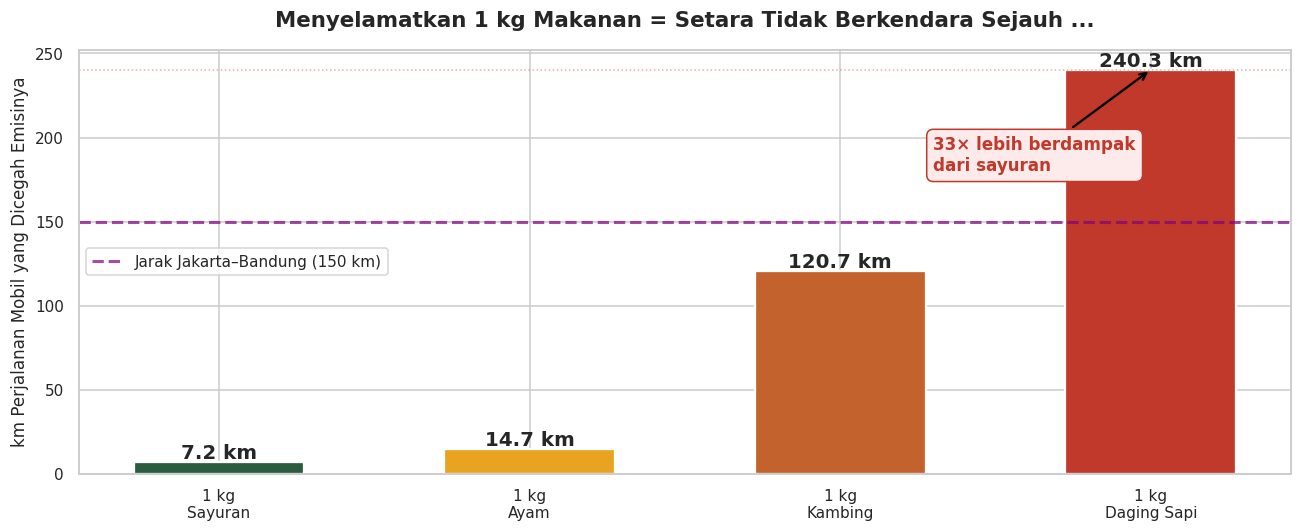


📌 Kesimpulan visual:
   • 1 kg sayuran diselamatkan  = setara tidak berkendara 7.2 km
   • 1 kg daging sapi diselamatkan = setara tidak berkendara 240.3 km
   • Rasio perbedaan: 33× lipat lebih berdampak!


In [26]:
# ── Visualisasi perbandingan daging sapi vs sayuran (untuk slide presentasi) ──
fig, ax = plt.subplots(figsize=(12, 5))

sapi_km    = 50.46 / CO2_PER_KM_CAR
sayur_km   = 1.52  / CO2_PER_KM_CAR
kambing_km = 25.35 / CO2_PER_KM_CAR
ayam_km    = 3.08  / CO2_PER_KM_CAR

items  = ['1 kg\nSayuran', '1 kg\nAyam', '1 kg\nKambing', '1 kg\nDaging Sapi']
values = [sayur_km, ayam_km, kambing_km, sapi_km]
colors = [C_GREEN, C_GOLD, C_ORANGE, C_RED]

bars = ax.bar(items, values, color=colors, edgecolor='white',
              width=0.55, linewidth=1.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'{val:.1f} km', ha='center', fontsize=13, fontweight='bold')

ax.axhline(150, color='purple', linestyle='--', linewidth=2, alpha=0.7,
           label='Jarak Jakarta–Bandung (150 km)')
ax.axhline(sapi_km, color=C_RED, linestyle=':', linewidth=1, alpha=0.4)
ax.set_title('Menyelamatkan 1 kg Makanan = Setara Tidak Berkendara Sejauh ...',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('km Perjalanan Mobil yang Dicegah Emisinya', fontsize=11)
ax.legend(fontsize=10)

# Anotasi ratio
ax.annotate(
    f'{sapi_km/sayur_km:.0f}× lebih berdampak\ndari sayuran',
    xy=(3, sapi_km), xytext=(2.3, sapi_km * 0.75),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=11, fontweight='bold', color=C_RED,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDEAEA', edgecolor=C_RED)
)

plt.tight_layout()
plt.show()

print(f"\n📌 Kesimpulan visual:")
print(f"   • 1 kg sayuran diselamatkan  = setara tidak berkendara {sayur_km:.1f} km")
print(f"   • 1 kg daging sapi diselamatkan = setara tidak berkendara {sapi_km:.1f} km")
print(f"   • Rasio perbedaan: {sapi_km/sayur_km:.0f}× lipat lebih berdampak!")


### 💡 Insight — Pertanyaan Bisnis Karbon 3

**Temuan (basis: emisi mobil 0.21 kg CO₂e/km):**
- Menyelamatkan **1 kg daging sapi** setara dengan tidak berkendara sejauh **±240 km** (lebih jauh dari Jakarta–Bandung!)
- Menyelamatkan **1 kg sayuran** setara dengan tidak berkendara **±7 km**.
- Rasio perbedaannya adalah **~33× lipat** — menyelamatkan daging sapi jauh lebih berdampak per kilogram.
- **1 kg kambing** ≈ 121 km berkendara, **1 kg ayam** ≈ 15 km.

**Implikasi untuk SayurKita:**
- Dashboard *Jejak Hijau™* harus menampilkan **satuan km berkendara** sebagai default karena lebih mudah dipahami user dibanding angka CO₂e abstrak (jika fitur ini di realisasikan).
- Notifikasi expiry untuk protein hewani bisa menampilkan pesan seperti: *"Daging ayam ini hampir expired! Memasaknya bisa mencegah emisi setara 15 km berkendara."*
- Perbandingan ini valid sebagai konten edukasi di onboarding screen untuk meningkatkan kesadaran lingkungan pengguna.


---
# 📋 Ringkasan Eksekutif — Semua Temuan

## Bagian A: Dataset Resep Indonesia
| # | Pertanyaan | Jawaban Kunci | Implikasi Teknis |
|---|-----------|---------------|-----------------|
| 1 | Distribusi kategori | 8 kategori, CoV < 20% — seimbang | Strategi top-25/kategori valid ✅ |
| 2 | Bahan vs popularitas | r ≈ 0.09 (hampir tidak ada korelasi) | Bobot `skor_loves` (35%) sudah tepat ✅ |
| 3 | Bahan paling sering | Bawang putih, garam, bawang merah | Prioritaskan 15 bahan ini di Ingredients Master ✅ |
| 4 | Langkah vs popularitas | r ≈ 0.02 (tidak ada korelasi) | Bobot `skor_langkah` (20%) sudah tepat ✅ |

## Bagian B: Dataset Carbon Factors
| # | Pertanyaan | Jawaban Kunci | Implikasi Teknis |
|---|-----------|---------------|-----------------|
| 1 | Kategori emisi tertinggi | Daging sapi: ~50 kg CO₂e/kg — 33× sayuran | Prioritas notifikasi expiry protein hewani ✅ |
| 2 | Impact projection | 1.000 user aktif → ~81 ton CO₂e/bulan (campuran) | Angka dashboard komunitas yang compelling ✅ |
| 3 | Konversi relatable | 1 kg daging sapi = ~240 km berkendara | Tampilkan km di Jejak Hijau™ sebagai default ✅ |
